In [ ]:
!pip install langgraph
!pip install langchain
!pip install langsmith
!pip install langchain_groq
!pip install langchain_tavily
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [ ]:
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [46]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.3-70b-versatile", api_key=GROQ_API_KEY, streaming=True)

## Human In The Loop

Human in the loop feedback is used get human assistance on certain places where Agent requires, such as editing critical workflows so it should ask a human whether should i proceed or not..

Let's first do the basic things of StateGraph creation

In [47]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import add_messages

class State(TypedDict):
  messages : Annotated[list, add_messages]

In [48]:
from langchain_tavily import TavilySearch
search_tool = TavilySearch(max_results = 2, tavily_api_key = TAVILY_API_KEY)

Now we create a basic human_assistance tool which will help agent get assistance from the human

In [65]:
from langgraph.types import Command, interrupt # These two things we will use for this task
from langchain.tools import tool

def human_assistance(query: str) -> str:
  """Only Call this tool when the user is asking assistance from a human and agent cannot provide answer to the question. dont call this when you have enough information of providing the answer. Also provide proper answer to the user according to the assistance from human"""
  human_response = interrupt({"query" : query})
  return human_response["data"]

"interrupt" basically means we are interrupting the workflow or we are forcefully interrupting agent to ask for human approval or feddbacks

Now make sure to bind our tools with the model or llm

In [66]:
model_with_tools = model.bind_tools([search_tool, human_assistance])

Now create chatbot node to use in the StateGraph

In [67]:
def ChatBot(state:State):
  return {"messages" : [model_with_tools.invoke(state["messages"])]}

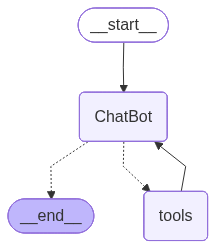

In [68]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(State)

builder.add_node("ChatBot", ChatBot)
builder.add_node("tools", ToolNode([search_tool, human_assistance]))

builder.add_edge(START, "ChatBot")
builder.add_conditional_edges("ChatBot", tools_condition)
builder.add_edge("tools", "ChatBot")

graph = builder.compile(checkpointer = MemorySaver())

graph




Now Lets try to call this

In [73]:
user_input = "I need some expert assistance on the LangGraph basic definiton only, would you please help me get some expert's human assistance"
config = {
    "configurable" : {
        "thread_id" : "user123"
    }
}

for chunk in graph.stream({"messages" : user_input}, config = config, stream_mode = "values"):
  chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert assistance on the LangGraph basic definiton only, would you please help me get some expert's human assistance
================================== Ai Message ==================================
Tool Calls:
  human_assistance (jwreytshg)
 Call ID: jwreytshg
  Args:
    query: LangGraph basic definition
================================== Ai Message ==================================
Tool Calls:
  human_assistance (jwreytshg)
 Call ID: jwreytshg
  Args:
    query: LangGraph basic definition


Now it stopped here, its expecting human to provide some kind of input back

Now we use Command to resume our conversation where it interrupted

In [74]:
human_reponse = "LangGraph is an amazing framework developed by the creators of LangChain, it help you create Agentic workflows and Agent systems to address multiple complex tasks"

human_command = Command(resume={"data" : human_reponse})

for chunk in graph.stream(human_command, config = config, stream_mode = "values"):
  chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (jwreytshg)
 Call ID: jwreytshg
  Args:
    query: LangGraph basic definition
================================= Tool Message =================================
Name: human_assistance

LangGraph is an amazing framework developed by the creators of LangChain, it help you create Agentic workflows and Agent systems to address multiple complex tasks
================================== Ai Message ==================================

The expert has provided the definition of LangGraph as "an amazing framework developed by the creators of LangChain, it helps you create Agentic workflows and Agent systems to address multiple complex tasks".
